# **imports**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import BallTree

from google.colab import drive
drive.mount('/content/drive', force_remount= True) #Use path /content/drive/MyDrive/Aerosol/files/ to access files

# **AERONET**

## **Loading the SSA Data**

In [ ]:
ssa_df = pd.read_csv('/content/drive/MyDrive/Aerosol/files/combined_ssa.csv')

In [ ]:
ssa_df

,AERONET_Site,Date(dd:mm:yyyy),Time(hh:mm:ss),Day_of_Year,Day_of_Year(Fraction),Single_Scattering_Albedo[440nm],Single_Scattering_Albedo[675nm],Single_Scattering_Albedo[870nm],Single_Scattering_Albedo[1020nm],Average_Solar_Zenith_Angles_for_Flux_Calculation(Degrees),...,Scattering_Angle_Bin_30_to_<80_degrees[667nm],Scattering_Angle_Bin_80_degrees_and_over[667nm],Surface_Albedo[443m],Surface_Albedo[667m],Single_Scattering_Albedo[865nm],Scattering_Angle_Bin_3.2_to_<6_degrees[865nm],Scattering_Angle_Bin_6_to_<30_degrees[865nm],Scattering_Angle_Bin_30_to_<80_degrees[865nm],Scattering_Angle_Bin_80_degrees_and_over[865nm],Surface_Albedo[865m]
0,Ussuriysk,11:01:2021,06:21:06,11,11.264653,0.6883,0.7052,0.6606,0.6210,77.888415,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ussuriysk,20:01:2021,04:24:15,20,20.183507,0.8778,0.9019,0.8731,0.8516,65.457731,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ussuriysk,20:01:2021,05:24:19,20,20.225220,0.9015,0.9302,0.9140,0.8969,69.864209,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Ussuriysk,25:01:2021,04:25:38,25,25.184468,0.7631,0.7977,0.7655,0.7220,64.328440,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Ussuriysk,25:01:2021,05:25:39,25,25.226146,0.8336,0.8270,0.8079,0.8000,68.801675,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92145,Chachoengsao,25:02:2021,08:29:52,56,56.354074,0.9349,0.9441,0.9404,0.9363,51.231392,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
92146,Chachoengsao,25:02:2021,09:58:56,56,56.415926,0.8876,0.8674,0.8492,0.8291,71.713140,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
92147,Chachoengsao,25:02:2021,10:24:38,56,56.433773,0.9012,0.8745,0.8510,0.8335,77.766697,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
92148,Chachoengsao,26:02:2021,09:59:02,57,57.415995,0.8711,0.8648,0.8570,0.8461,71.663848,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **Loading the SIZ Dataset**

In [ ]:
siz_df = pd.read_csv('/content/drive/MyDrive/Aerosol/files/combined_siz.csv')

In [ ]:
siz_df

,AERONET_Site,Date(dd:mm:yyyy),Time(hh:mm:ss),Day_of_Year,Day_of_Year(Fraction),0.050000,0.065604,0.086077,0.112939,0.148184,...,Scattering_Angle_Bin_6_to_<30_degrees[667nm],Scattering_Angle_Bin_30_to_<80_degrees[667nm],Scattering_Angle_Bin_80_degrees_and_over[667nm],Surface_Albedo[443m],Surface_Albedo[667m],Scattering_Angle_Bin_3.2_to_<6_degrees[865nm],Scattering_Angle_Bin_6_to_<30_degrees[865nm],Scattering_Angle_Bin_30_to_<80_degrees[865nm],Scattering_Angle_Bin_80_degrees_and_over[865nm],Surface_Albedo[865m]
0,Ussuriysk,11:01:2021,06:21:06,11,11.264653,0.000394,0.001231,0.002935,0.005430,0.008043,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ussuriysk,20:01:2021,04:24:15,20,20.183507,0.000836,0.001140,0.002013,0.004547,0.012270,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ussuriysk,20:01:2021,05:24:19,20,20.225220,0.000614,0.003544,0.011651,0.024069,0.039078,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Ussuriysk,25:01:2021,04:25:38,25,25.184468,0.000373,0.001925,0.006540,0.014655,0.022076,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Ussuriysk,25:01:2021,05:25:39,25,25.226146,0.000532,0.006055,0.030469,0.069944,0.080787,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92145,Chachoengsao,25:02:2021,08:29:52,56,56.354074,0.000497,0.002580,0.010502,0.032507,0.068686,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
92146,Chachoengsao,25:02:2021,09:58:56,56,56.415926,0.000595,0.004401,0.019886,0.055824,0.096110,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
92147,Chachoengsao,25:02:2021,10:24:38,56,56.433773,0.000706,0.005253,0.023393,0.059770,0.087029,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
92148,Chachoengsao,26:02:2021,09:59:02,57,57.415995,0.000389,0.002773,0.014530,0.049740,0.088395,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **Getting necessary data**

In [ ]:
ssa_df.columns

Index(['AERONET_Site', 'Date(dd:mm:yyyy)', 'Time(hh:mm:ss)', 'Day_of_Year',
       'Day_of_Year(Fraction)', 'Single_Scattering_Albedo[440nm]',
       'Single_Scattering_Albedo[675nm]', 'Single_Scattering_Albedo[870nm]',
       'Single_Scattering_Albedo[1020nm]',
       'Average_Solar_Zenith_Angles_for_Flux_Calculation(Degrees)',
       'Solar_Zenith_Angle_for_Measurement_Start(Degrees)', 'Sky_Residual(%)',
       'Sun_Residual(%)', 'Coincident_AOD440nm',
       'Scattering_Angle_Bin_3.2_to_<6_degrees[440nm]',
       'Scattering_Angle_Bin_6_to_<30_degrees[440nm]',
       'Scattering_Angle_Bin_30_to_<80_degrees[440nm]',
       'Scattering_Angle_Bin_80_degrees_and_over[440nm]',
       'Scattering_Angle_Bin_3.2_to_<6_degrees[675nm]',
       'Scattering_Angle_Bin_6_to_<30_degrees[675nm]',
       'Scattering_Angle_Bin_30_to_<80_degrees[675nm]',
       'Scattering_Angle_Bin_80_degrees_and_over[675nm]',
       'Scattering_Angle_Bin_3.2_to_<6_degrees[870nm]',
       'Scattering_Angle_Bin_6_to_<

In [ ]:
# Selecting Important Columns
cols = ['AERONET_Site','Date(dd:mm:yyyy)', 'Time(hh:mm:ss)', 'Single_Scattering_Albedo[440nm]','Single_Scattering_Albedo[675nm]','Single_Scattering_Albedo[870nm]','Single_Scattering_Albedo[1020nm]','Solar_Zenith_Angle_for_Measurement_Start(Degrees)', 'Coincident_AOD440nm', 'Latitude(Degrees)','Longitude(Degrees)','Elevation(m)']
ssa_df = ssa_df[cols]

In [ ]:
ssa_df

,AERONET_Site,Date(dd:mm:yyyy),Time(hh:mm:ss),Single_Scattering_Albedo[440nm],Single_Scattering_Albedo[675nm],Single_Scattering_Albedo[870nm],Single_Scattering_Albedo[1020nm],Solar_Zenith_Angle_for_Measurement_Start(Degrees),Coincident_AOD440nm,Latitude(Degrees),Longitude(Degrees),Elevation(m)
0,Ussuriysk,11:01:2021,06:21:06,0.6883,0.7052,0.6606,0.6210,77.521292,0.176030,43.7004,132.1635,280.0
1,Ussuriysk,20:01:2021,04:24:15,0.8778,0.9019,0.8731,0.8516,65.305465,0.580506,43.7004,132.1635,280.0
2,Ussuriysk,20:01:2021,05:24:19,0.9015,0.9302,0.9140,0.8969,69.586855,0.892223,43.7004,132.1635,280.0
3,Ussuriysk,25:01:2021,04:25:38,0.7631,0.7977,0.7655,0.7220,64.173469,0.347806,43.7004,132.1635,280.0
4,Ussuriysk,25:01:2021,05:25:39,0.8336,0.8270,0.8079,0.8000,68.520239,0.476816,43.7004,132.1635,280.0
...,...,...,...,...,...,...,...,...,...,...,...,...
92145,Chachoengsao,25:02:2021,08:29:52,0.9349,0.9441,0.9404,0.9363,50.564117,0.809881,13.5000,101.4500,60.0
92146,Chachoengsao,25:02:2021,09:58:56,0.8876,0.8674,0.8492,0.8291,71.008821,0.819742,13.5000,101.4500,60.0
92147,Chachoengsao,25:02:2021,10:24:38,0.9012,0.8745,0.8510,0.8335,77.058777,0.879299,13.5000,101.4500,60.0
92148,Chachoengsao,26:02:2021,09:59:02,0.8711,0.8648,0.8570,0.8461,70.958276,0.545511,13.5000,101.4500,60.0


In [ ]:
siz_df.columns

Index(['AERONET_Site', 'Date(dd:mm:yyyy)', 'Time(hh:mm:ss)', 'Day_of_Year',
       'Day_of_Year(Fraction)', '0.050000', '0.065604', '0.086077', '0.112939',
       '0.148184', '0.194429', '0.255105', '0.334716', '0.439173', '0.576227',
       '0.756052', '0.991996', '1.301571', '1.707757', '2.240702', '2.939966',
       '3.857452', '5.061260', '6.640745', '8.713145', '11.432287',
       '15.000000', 'Inflection_Radius_of_Size_Distribution(um)',
       'Average_Solar_Zenith_Angles_for_Flux_Calculation(Degrees)',
       'Solar_Zenith_Angle_for_Measurement_Start(Degrees)', 'Sky_Residual(%)',
       'Sun_Residual(%)', 'Coincident_AOD440nm',
       'Scattering_Angle_Bin_3.2_to_<6_degrees[440nm]',
       'Scattering_Angle_Bin_6_to_<30_degrees[440nm]',
       'Scattering_Angle_Bin_30_to_<80_degrees[440nm]',
       'Scattering_Angle_Bin_80_degrees_and_over[440nm]',
       'Scattering_Angle_Bin_3.2_to_<6_degrees[675nm]',
       'Scattering_Angle_Bin_6_to_<30_degrees[675nm]',
       'Scattering_A

In [ ]:
# Selecting Important Columns
cols2 = ['AERONET_Site',	'Date(dd:mm:yyyy)',	'Time(hh:mm:ss)',	'Day_of_Year',	'Day_of_Year(Fraction)', '0.050000', '0.065604', '0.086077', '0.112939',
       '0.148184', '0.194429', '0.255105', '0.334716', '0.439173', '0.576227',
       '0.756052', '0.991996', '1.301571', '1.707757', '2.240702', '2.939966',
       '3.857452', '5.061260', '6.640745', '8.713145', '11.432287',
       '15.000000', 'Coincident_AOD440nm', 'Latitude(Degrees)', 'Longitude(Degrees)',
       'Elevation(m)']
siz_df = siz_df[cols2]

In [ ]:
siz_df

,AERONET_Site,Date(dd:mm:yyyy),Time(hh:mm:ss),Day_of_Year,Day_of_Year(Fraction),0.050000,0.065604,0.086077,0.112939,0.148184,...,3.857452,5.061260,6.640745,8.713145,11.432287,15.000000,Coincident_AOD440nm,Latitude(Degrees),Longitude(Degrees),Elevation(m)
0,Ussuriysk,11:01:2021,06:21:06,11,11.264653,0.000394,0.001231,0.002935,0.005430,0.008043,...,0.033528,0.037082,0.027413,0.012075,0.002978,0.000402,0.176030,43.7004,132.1635,280.0
1,Ussuriysk,20:01:2021,04:24:15,20,20.183507,0.000836,0.001140,0.002013,0.004547,0.012270,...,0.030226,0.017218,0.009620,0.005189,0.002588,0.001160,0.580506,43.7004,132.1635,280.0
2,Ussuriysk,20:01:2021,05:24:19,20,20.225220,0.000614,0.003544,0.011651,0.024069,0.039078,...,0.026403,0.021466,0.016332,0.009382,0.003386,0.000708,0.892223,43.7004,132.1635,280.0
3,Ussuriysk,25:01:2021,04:25:38,25,25.184468,0.000373,0.001925,0.006540,0.014655,0.022076,...,0.007896,0.004353,0.002564,0.001566,0.000954,0.000568,0.347806,43.7004,132.1635,280.0
4,Ussuriysk,25:01:2021,05:25:39,25,25.226146,0.000532,0.006055,0.030469,0.069944,0.080787,...,0.016317,0.007908,0.003704,0.001733,0.000819,0.000392,0.476816,43.7004,132.1635,280.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92145,Chachoengsao,25:02:2021,08:29:52,56,56.354074,0.000497,0.002580,0.010502,0.032507,0.068686,...,0.034546,0.026893,0.015761,0.007095,0.002479,0.000672,0.809881,13.5000,101.4500,60.0
92146,Chachoengsao,25:02:2021,09:58:56,56,56.415926,0.000595,0.004401,0.019886,0.055824,0.096110,...,0.042584,0.042464,0.029125,0.013000,0.003712,0.000665,0.819742,13.5000,101.4500,60.0
92147,Chachoengsao,25:02:2021,10:24:38,56,56.433773,0.000706,0.005253,0.023393,0.059770,0.087029,...,0.043845,0.046643,0.035441,0.016046,0.004317,0.000738,0.879299,13.5000,101.4500,60.0
92148,Chachoengsao,26:02:2021,09:59:02,57,57.415995,0.000389,0.002773,0.014530,0.049740,0.088395,...,0.036773,0.038936,0.026005,0.010275,0.002544,0.000413,0.545511,13.5000,101.4500,60.0


## **Classification of Aerosol type using fine and coarse mode:**

In [ ]:
fine_mode = siz_df.iloc[:, 5:17]
coarse_mode = siz_df.iloc[:, 17:27]

fine_volume = fine_mode.sum(axis=1)
coarse_volume = coarse_mode.sum(axis=1)

In [ ]:
dust_ratio = coarse_volume / (fine_volume + coarse_volume)

siz_df['Dust_Ratio'] = dust_ratio

siz_df.head()

/tmp/ipython-input-13-2233731472.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  siz_df['Dust_Ratio'] = dust_ratio


,AERONET_Site,Date(dd:mm:yyyy),Time(hh:mm:ss),Day_of_Year,Day_of_Year(Fraction),0.050000,0.065604,0.086077,0.112939,0.148184,...,5.061260,6.640745,8.713145,11.432287,15.000000,Coincident_AOD440nm,Latitude(Degrees),Longitude(Degrees),Elevation(m),Dust_Ratio
0,Ussuriysk,11:01:2021,06:21:06,11,11.264653,0.000394,0.001231,0.002935,0.005430,0.008043,...,0.037082,0.027413,0.012075,0.002978,0.000402,0.176030,43.7004,132.1635,280.0,0.677970
1,Ussuriysk,20:01:2021,04:24:15,20,20.183507,0.000836,0.001140,0.002013,0.004547,0.012270,...,0.017218,0.009620,0.005189,0.002588,0.001160,0.580506,43.7004,132.1635,280.0,0.522403
2,Ussuriysk,20:01:2021,05:24:19,20,20.225220,0.000614,0.003544,0.011651,0.024069,0.039078,...,0.021466,0.016332,0.009382,0.003386,0.000708,0.892223,43.7004,132.1635,280.0,0.336654
3,Ussuriysk,25:01:2021,04:25:38,25,25.184468,0.000373,0.001925,0.006540,0.014655,0.022076,...,0.004353,0.002564,0.001566,0.000954,0.000568,0.347806,43.7004,132.1635,280.0,0.454616
4,Ussuriysk,25:01:2021,05:25:39,25,25.226146,0.000532,0.006055,0.030469,0.069944,0.080787,...,0.007908,0.003704,0.001733,0.000819,0.000392,0.476816,43.7004,132.1635,280.0,0.343680


In [ ]:
siz_df['Coincident_AOD440nm']

,Coincident_AOD440nm
0,0.176030
1,0.580506
2,0.892223
3,0.347806
4,0.476816
...,...
92145,0.809881
92146,0.819742
92147,0.879299
92148,0.545511


In [ ]:
ssa_df['Datetime'] = pd.to_datetime(ssa_df['Date(dd:mm:yyyy)'] + ' ' + ssa_df['Time(hh:mm:ss)'], format='%d:%m:%Y %H:%M:%S')
siz_df['Datetime'] = pd.to_datetime(siz_df['Date(dd:mm:yyyy)'] + ' ' + siz_df['Time(hh:mm:ss)'], format='%d:%m:%Y %H:%M:%S')

/tmp/ipython-input-15-4216991849.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ssa_df['Datetime'] = pd.to_datetime(ssa_df['Date(dd:mm:yyyy)'] + ' ' + ssa_df['Time(hh:mm:ss)'], format='%d:%m:%Y %H:%M:%S')
/tmp/ipython-input-15-4216991849.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  siz_df['Datetime'] = pd.to_datetime(siz_df['Date(dd:mm:yyyy)'] + ' ' + siz_df['Time(hh:mm:ss)'], format='%d:%m:%Y %H:%M:%S')


In [ ]:
ssa_df.columns

Index(['AERONET_Site', 'Date(dd:mm:yyyy)', 'Time(hh:mm:ss)',
       'Single_Scattering_Albedo[440nm]', 'Single_Scattering_Albedo[675nm]',
       'Single_Scattering_Albedo[870nm]', 'Single_Scattering_Albedo[1020nm]',
       'Solar_Zenith_Angle_for_Measurement_Start(Degrees)',
       'Coincident_AOD440nm', 'Latitude(Degrees)', 'Longitude(Degrees)',
       'Elevation(m)', 'Datetime'],
      dtype='object')

In [ ]:
siz_df.columns

Index(['AERONET_Site', 'Date(dd:mm:yyyy)', 'Time(hh:mm:ss)', 'Day_of_Year',
       'Day_of_Year(Fraction)', '0.050000', '0.065604', '0.086077', '0.112939',
       '0.148184', '0.194429', '0.255105', '0.334716', '0.439173', '0.576227',
       '0.756052', '0.991996', '1.301571', '1.707757', '2.240702', '2.939966',
       '3.857452', '5.061260', '6.640745', '8.713145', '11.432287',
       '15.000000', 'Coincident_AOD440nm', 'Latitude(Degrees)',
       'Longitude(Degrees)', 'Elevation(m)', 'Dust_Ratio', 'Datetime'],
      dtype='object')

In [ ]:
import pandas as pd

# Define common merge keys
merge_keys = ['Latitude(Degrees)', 'Longitude(Degrees)', 'Elevation(m)', 'Datetime']

# Optional: Ensure Datetime is actually datetime type (for safe merging)
ssa_df['Datetime'] = pd.to_datetime(ssa_df['Datetime'])
siz_df['Datetime'] = pd.to_datetime(siz_df['Datetime'])

# Step 1: Drop duplicates in siz_df on the merge keys
siz_df_unique = siz_df.drop_duplicates(subset=merge_keys).copy()

# Step 2: Align data types for all merge keys (use string if unsure)
for col in merge_keys:
    ssa_df.loc[:, col] = ssa_df[col].astype(str)
    siz_df_unique.loc[:, col] = siz_df_unique[col].astype(str)

# Step 3: Merge only Dust_Ratio from siz_df into ssa_df
merged_df = ssa_df.merge(
    siz_df_unique[merge_keys + ['Dust_Ratio']],
    on=merge_keys,
    how='inner'  # or 'inner' if you only want rows that exist in both
)

# Final output
print(f"Merged shape: {merged_df.shape}")
merged_df.head()

/tmp/ipython-input-18-1520388229.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ssa_df['Datetime'] = pd.to_datetime(ssa_df['Datetime'])
/tmp/ipython-input-18-1520388229.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  siz_df['Datetime'] = pd.to_datetime(siz_df['Datetime'])
/tmp/ipython-input-18-1520388229.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['43.7004' '43.7004' '43.7004' ... '13.5' '13.5' '13.5']' has dtype inco

Merged shape: (92150, 14)


,AERONET_Site,Date(dd:mm:yyyy),Time(hh:mm:ss),Single_Scattering_Albedo[440nm],Single_Scattering_Albedo[675nm],Single_Scattering_Albedo[870nm],Single_Scattering_Albedo[1020nm],Solar_Zenith_Angle_for_Measurement_Start(Degrees),Coincident_AOD440nm,Latitude(Degrees),Longitude(Degrees),Elevation(m),Datetime,Dust_Ratio
0,Ussuriysk,11:01:2021,06:21:06,0.6883,0.7052,0.6606,0.6210,77.521292,0.176030,43.7004,132.1635,280.0,2021-01-11 06:21:06,0.677970
1,Ussuriysk,20:01:2021,04:24:15,0.8778,0.9019,0.8731,0.8516,65.305465,0.580506,43.7004,132.1635,280.0,2021-01-20 04:24:15,0.522403
2,Ussuriysk,20:01:2021,05:24:19,0.9015,0.9302,0.9140,0.8969,69.586855,0.892223,43.7004,132.1635,280.0,2021-01-20 05:24:19,0.336654
3,Ussuriysk,25:01:2021,04:25:38,0.7631,0.7977,0.7655,0.7220,64.173469,0.347806,43.7004,132.1635,280.0,2021-01-25 04:25:38,0.454616
4,Ussuriysk,25:01:2021,05:25:39,0.8336,0.8270,0.8079,0.8000,68.520239,0.476816,43.7004,132.1635,280.0,2021-01-25 05:25:39,0.343680


In [ ]:
merged_df.shape

(92150, 14)

In [ ]:
common_keys = set(
    tuple(row) for row in ssa_df[['Latitude(Degrees)', 'Longitude(Degrees)', 'Elevation(m)', 'Datetime']].values
) & set(
    tuple(row) for row in siz_df[['Latitude(Degrees)', 'Longitude(Degrees)', 'Elevation(m)', 'Datetime']].values
)

print(f"Number of common rows: {len(common_keys)}")

Number of common rows: 0


In [ ]:
def classify_aerosol(row):
    rd = row['Dust_Ratio']
    ssa = row['Single_Scattering_Albedo[440nm]']

    if rd > 0.89:
        return 0
    elif 0.53 <= rd <= 0.89:
        return 1
    elif 0.17 <= rd < 0.53:
        return 2
    elif rd < 0.17:
        if ssa > 0.95:
            return 3
        elif 0.90 < ssa <= 0.95:
            return 4
        elif 0.85 <= ssa <= 0.90:
            return 5
        elif ssa < 0.85:
            return 6
    return -1

merged_df['Aerosol_Type'] = merged_df.apply(classify_aerosol, axis=1)

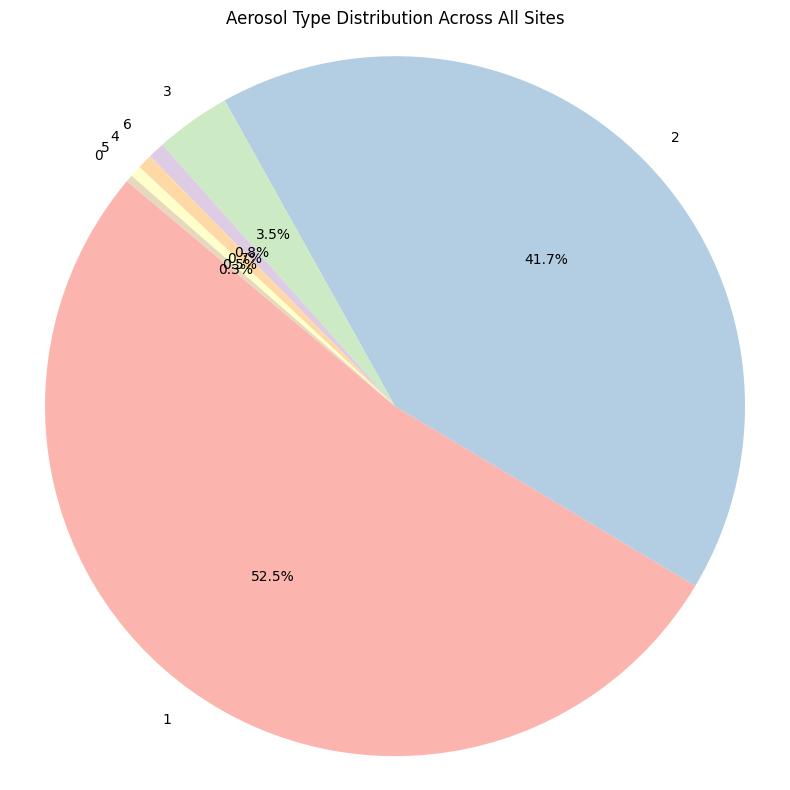

In [ ]:
# Count aerosol types
aerosol_counts = merged_df['Aerosol_Type'].value_counts()

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(aerosol_counts, labels=aerosol_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Pastel1.colors)
plt.title('Aerosol Type Distribution Across All Sites')
plt.axis('equal')
plt.tight_layout()
plt.show()


In [ ]:
merged_df.head()

,AERONET_Site,Date(dd:mm:yyyy),Time(hh:mm:ss),Single_Scattering_Albedo[440nm],Single_Scattering_Albedo[675nm],Single_Scattering_Albedo[870nm],Single_Scattering_Albedo[1020nm],Solar_Zenith_Angle_for_Measurement_Start(Degrees),Coincident_AOD440nm,Latitude(Degrees),Longitude(Degrees),Elevation(m),Datetime,Dust_Ratio,Aerosol_Type
0,Ussuriysk,11:01:2021,06:21:06,0.6883,0.7052,0.6606,0.6210,77.521292,0.176030,43.7004,132.1635,280.0,2021-01-11 06:21:06,0.677970,1
1,Ussuriysk,20:01:2021,04:24:15,0.8778,0.9019,0.8731,0.8516,65.305465,0.580506,43.7004,132.1635,280.0,2021-01-20 04:24:15,0.522403,2
2,Ussuriysk,20:01:2021,05:24:19,0.9015,0.9302,0.9140,0.8969,69.586855,0.892223,43.7004,132.1635,280.0,2021-01-20 05:24:19,0.336654,2
3,Ussuriysk,25:01:2021,04:25:38,0.7631,0.7977,0.7655,0.7220,64.173469,0.347806,43.7004,132.1635,280.0,2021-01-25 04:25:38,0.454616,2
4,Ussuriysk,25:01:2021,05:25:39,0.8336,0.8270,0.8079,0.8000,68.520239,0.476816,43.7004,132.1635,280.0,2021-01-25 05:25:39,0.343680,2


## **Loading the LIZ Data**

In [ ]:
liz = pd.read_csv('/content/drive/MyDrive/Aerosol/files/combined_lid.csv')

In [ ]:
liz.head()

,AERONET_Site,Date(dd:mm:yyyy),Time(hh:mm:ss),Day_of_Year,Day_of_Year(Fraction),Lidar_Ratio[440nm],Lidar_Ratio[675nm],Lidar_Ratio[870nm],Lidar_Ratio[1020nm],Depolarization_Ratio[440nm],...,Scattering_Angle_Bin_80_degrees_and_over[667nm],Surface_Albedo[443m],Surface_Albedo[667m],Lidar_Ratio[865nm],Depolarization_Ratio[865nm],Scattering_Angle_Bin_3.2_to_<6_degrees[865nm],Scattering_Angle_Bin_6_to_<30_degrees[865nm],Scattering_Angle_Bin_30_to_<80_degrees[865nm],Scattering_Angle_Bin_80_degrees_and_over[865nm],Surface_Albedo[865m]
0,Ussuriysk,11:01:2021,06:21:06,11,11.264653,143.660,116.040,118.700,127.820,0.003262,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ussuriysk,20:01:2021,04:24:15,20,20.183507,80.597,84.445,80.956,79.447,0.004649,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ussuriysk,20:01:2021,05:24:19,20,20.225220,106.550,79.974,70.614,66.471,0.003701,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Ussuriysk,25:01:2021,04:25:38,25,25.184468,149.980,94.861,83.128,84.908,0.110120,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Ussuriysk,25:01:2021,05:25:39,25,25.226146,119.780,67.319,57.510,56.623,0.004705,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
liz.shape

(92150, 70)

In [ ]:
liz.columns

Index(['AERONET_Site', 'Date(dd:mm:yyyy)', 'Time(hh:mm:ss)', 'Day_of_Year',
       'Day_of_Year(Fraction)', 'Lidar_Ratio[440nm]', 'Lidar_Ratio[675nm]',
       'Lidar_Ratio[870nm]', 'Lidar_Ratio[1020nm]',
       'Depolarization_Ratio[440nm]', 'Depolarization_Ratio[675nm]',
       'Depolarization_Ratio[870nm]', 'Depolarization_Ratio[1020nm]',
       'Average_Solar_Zenith_Angles_for_Flux_Calculation(Degrees)',
       'Solar_Zenith_Angle_for_Measurement_Start(Degrees)', 'Sky_Residual(%)',
       'Sun_Residual(%)', 'Coincident_AOD440nm',
       'Scattering_Angle_Bin_3.2_to_<6_degrees[440nm]',
       'Scattering_Angle_Bin_6_to_<30_degrees[440nm]',
       'Scattering_Angle_Bin_30_to_<80_degrees[440nm]',
       'Scattering_Angle_Bin_80_degrees_and_over[440nm]',
       'Scattering_Angle_Bin_3.2_to_<6_degrees[675nm]',
       'Scattering_Angle_Bin_6_to_<30_degrees[675nm]',
       'Scattering_Angle_Bin_30_to_<80_degrees[675nm]',
       'Scattering_Angle_Bin_80_degrees_and_over[675nm]',
       'Sca

In [ ]:
cols3 = ['AERONET_Site', 'Date(dd:mm:yyyy)',	'Time(hh:mm:ss)', 'Day_of_Year',	'Day_of_Year(Fraction)', 'Depolarization_Ratio[1020nm]', 'Latitude(Degrees)', 'Longitude(Degrees)',
       'Elevation(m)']
liz = liz[cols3]

## **Classification of Aerosol type using PLDR:**

In [ ]:
dp_dust= 0.32
dp_nondust= 0.03
liz.loc[:, "Dust_Ratio_PLDR"] = ((liz["Depolarization_Ratio[1020nm]"]-dp_nondust)*(1+dp_dust))/((dp_dust-dp_nondust)*(1+liz["Depolarization_Ratio[1020nm]"]))
liz.head()

,AERONET_Site,Date(dd:mm:yyyy),Time(hh:mm:ss),Day_of_Year,Day_of_Year(Fraction),Depolarization_Ratio[1020nm],Latitude(Degrees),Longitude(Degrees),Elevation(m),Dust_Ratio_PLDR
0,Ussuriysk,11:01:2021,06:21:06,11,11.264653,0.006246,43.7004,132.1635,280.0,-0.107451
1,Ussuriysk,20:01:2021,04:24:15,20,20.183507,0.004833,43.7004,132.1635,280.0,-0.114002
2,Ussuriysk,20:01:2021,05:24:19,20,20.225220,0.002733,43.7004,132.1635,280.0,-0.123774
3,Ussuriysk,25:01:2021,04:25:38,25,25.184468,0.060689,43.7004,132.1635,280.0,0.131695
4,Ussuriysk,25:01:2021,05:25:39,25,25.226146,0.003674,43.7004,132.1635,280.0,-0.119390


In [ ]:
liz.loc[:, 'Datetime'] = pd.to_datetime(liz['Date(dd:mm:yyyy)'] + ' ' + liz['Time(hh:mm:ss)'], format='%d:%m:%Y %H:%M:%S')

In [ ]:
# Define common merge keys
merge_keys_liz = ['Latitude(Degrees)', 'Longitude(Degrees)', 'Elevation(m)', 'Datetime']

# Optional: Ensure Datetime is actually datetime type (for safe merging)
merged_df['Datetime'] = pd.to_datetime(merged_df['Datetime'])
liz.loc[:, 'Datetime'] = pd.to_datetime(liz['Datetime'])

# Step 1: Drop duplicates in liz on the merge keys
liz_df_unique = liz.drop_duplicates(subset=merge_keys_liz).copy()

# Step 2: Align data types for all merge keys (use string if unsure)
for col in merge_keys_liz:
    merged_df[col] = merged_df[col].astype(str)
    liz_df_unique[col] = liz_df_unique[col].astype(str)

# Step 3: Merge only Dust_Ratio_PLDR from liz into merged_df
merged_df = merged_df.merge(
    liz_df_unique[merge_keys_liz + ['Dust_Ratio_PLDR']],
    on=merge_keys_liz,
    how='inner'  # or 'inner' if you only want rows that exist in both
)

# Final output
print(f"Merged shape: {merged_df.shape}")
merged_df.head()

Merged shape: (92150, 16)


,AERONET_Site,Date(dd:mm:yyyy),Time(hh:mm:ss),Single_Scattering_Albedo[440nm],Single_Scattering_Albedo[675nm],Single_Scattering_Albedo[870nm],Single_Scattering_Albedo[1020nm],Solar_Zenith_Angle_for_Measurement_Start(Degrees),Coincident_AOD440nm,Latitude(Degrees),Longitude(Degrees),Elevation(m),Datetime,Dust_Ratio,Aerosol_Type,Dust_Ratio_PLDR
0,Ussuriysk,11:01:2021,06:21:06,0.6883,0.7052,0.6606,0.6210,77.521292,0.176030,43.7004,132.1635,280.0,2021-01-11 06:21:06,0.677970,1,-0.107451
1,Ussuriysk,20:01:2021,04:24:15,0.8778,0.9019,0.8731,0.8516,65.305465,0.580506,43.7004,132.1635,280.0,2021-01-20 04:24:15,0.522403,2,-0.114002
2,Ussuriysk,20:01:2021,05:24:19,0.9015,0.9302,0.9140,0.8969,69.586855,0.892223,43.7004,132.1635,280.0,2021-01-20 05:24:19,0.336654,2,-0.123774
3,Ussuriysk,25:01:2021,04:25:38,0.7631,0.7977,0.7655,0.7220,64.173469,0.347806,43.7004,132.1635,280.0,2021-01-25 04:25:38,0.454616,2,0.131695
4,Ussuriysk,25:01:2021,05:25:39,0.8336,0.8270,0.8079,0.8000,68.520239,0.476816,43.7004,132.1635,280.0,2021-01-25 05:25:39,0.343680,2,-0.119390


In [ ]:
def classify_aerosol(row):
    rd = row['Dust_Ratio_PLDR']
    ssa = row['Single_Scattering_Albedo[440nm]']

    if rd > 0.89:
        return 0
    elif 0.53 <= rd <= 0.89:
        return 1
    elif 0.17 <= rd < 0.53:
        return 2
    elif rd < 0.17:
        if ssa > 0.95:
            return 3
        elif 0.90 < ssa <= 0.95:
            return 4
        elif 0.85 <= ssa <= 0.90:
            return 5
        elif ssa < 0.85:
            return 6
    return -1

merged_df['Aerosol_Type_PLDR'] = merged_df.apply(classify_aerosol, axis=1)

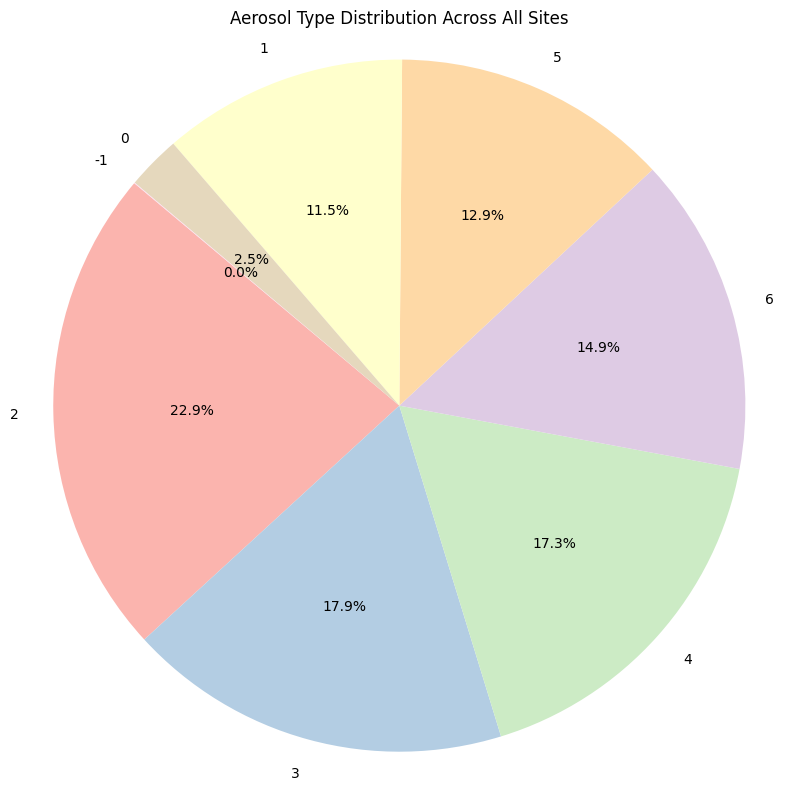

In [ ]:
# Count aerosol types
aerosol_counts = merged_df['Aerosol_Type_PLDR'].value_counts()

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(aerosol_counts, labels=aerosol_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Pastel1.colors)
plt.title('Aerosol Type Distribution Across All Sites')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [ ]:
merged_df.head()

,AERONET_Site,Date(dd:mm:yyyy),Time(hh:mm:ss),Single_Scattering_Albedo[440nm],Single_Scattering_Albedo[675nm],Single_Scattering_Albedo[870nm],Single_Scattering_Albedo[1020nm],Solar_Zenith_Angle_for_Measurement_Start(Degrees),Coincident_AOD440nm,Latitude(Degrees),Longitude(Degrees),Elevation(m),Datetime,Dust_Ratio,Aerosol_Type,Dust_Ratio_PLDR,Aerosol_Type_PLDR
0,Ussuriysk,11:01:2021,06:21:06,0.6883,0.7052,0.6606,0.6210,77.521292,0.176030,43.7004,132.1635,280.0,2021-01-11 06:21:06,0.677970,1,0.020148,6
1,Ussuriysk,20:01:2021,04:24:15,0.8778,0.9019,0.8731,0.8516,65.305465,0.580506,43.7004,132.1635,280.0,2021-01-20 04:24:15,0.522403,2,0.015590,5
2,Ussuriysk,20:01:2021,05:24:19,0.9015,0.9302,0.9140,0.8969,69.586855,0.892223,43.7004,132.1635,280.0,2021-01-20 05:24:19,0.336654,2,0.008816,4
3,Ussuriysk,25:01:2021,04:25:38,0.7631,0.7977,0.7655,0.7220,64.173469,0.347806,43.7004,132.1635,280.0,2021-01-25 04:25:38,0.454616,2,0.195771,2
4,Ussuriysk,25:01:2021,05:25:39,0.8336,0.8270,0.8079,0.8000,68.520239,0.476816,43.7004,132.1635,280.0,2021-01-25 05:25:39,0.343680,2,0.011852,6


In [ ]:
merged_df.replace(-999, np.nan, inplace=True)
merged_df.dropna(inplace=True)
merged_df.shape

(92037, 17)

In [ ]:
merged_df.to_csv("/content/drive/MyDrive/Aerosol/files/aeronet.csv", index=False)